# hj_reachability quickstart

Notebook dependencies:
- System: python3, ffmpeg (for rendering animations)
- Python: jupyter, jax, numpy, matplotlib, plotly, tqdm, hj_reachability

Example setup for a Ubuntu system (Mac users, maybe `brew` instead of `sudo apt`; Windows users, learn to love [WSL](https://docs.microsoft.com/en-us/windows/wsl/install-win10)):
```
sudo apt install ffmpeg
/usr/bin/python3 -m pip install --upgrade pip
pip install --upgrade jupyter jax[cpu] numpy matplotlib plotly tqdm hj-reachability
jupyter notebook  # from the directory of this notebook
```
Alternatively, view this notebook on [Google Colab](https://colab.research.google.com/github/StanfordASL/hj_reachability/blob/main/examples/quickstart.ipynb) and run a cell containing this command:
```
!pip install --upgrade hj-reachability
```

In [1]:
import jax
import jax.numpy as jnp
import numpy as np

from IPython.display import HTML
import matplotlib.animation as anim
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import hj_reachability as hj

from hj_reachability.systems.doubleint import DoubleIntegrator

/home/radams4r/HSL/.venv/lib/python3.12/site-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.10.1 is installed, but it is not compatible with the installed jaxlib version 0.10.2, so it will not be used.
  warnings.warn(


## Example system: `Double Integrator`

In [ ]:
# dynamics = hj.systems.Air3d()
u_max = 1.0
d_max = 1.0
dynamics = DoubleIntegrator(u_max=u_max, d_max=d_max)

grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(
    hj.sets.Box(np.array([-20., -10.]), np.array([20., 10.])),
    (101, 50)
)

safety_bound = 10

values = jnp.linalg.norm(grid.states[..., :2], axis=-1) - safety_bound

solver_settings = hj.SolverSettings.with_accuracy("very_high",
                                                  hamiltonian_postprocessor=hj.solver.backwards_reachable_tube)

### `hj.step`: propagate the HJ PDE from `(time, values)` to `target_time`.

In [3]:
time = 0.
target_time = -2
target_values = hj.step(solver_settings, dynamics, grid, time, values, target_time)

100%|##########|  2.0000/2.0 [00:00<00:00, 20.54sim_s/s]


Text(0.5, 1.0, 'Double Integrator Reachable Sets (safety bound=10, u_max=1.0, d_max=1.0) at time 2')

<Figure size 640x480 with 0 Axes>

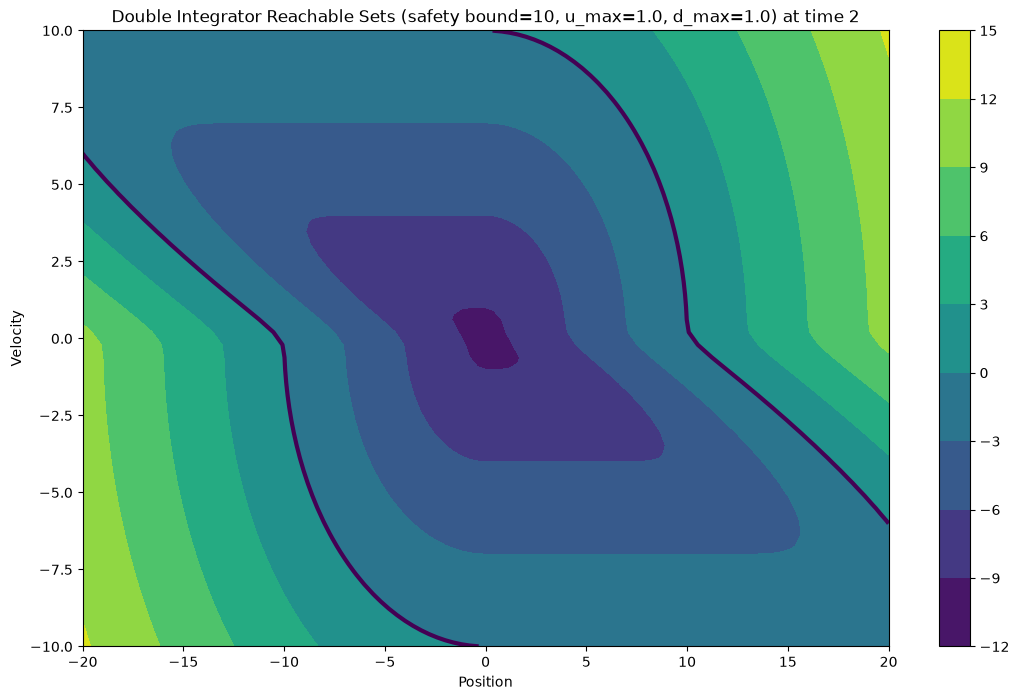

In [ ]:
plt.jet()
plt.figure(figsize=(13, 8))

plt.contourf(grid.coordinate_vectors[0], 
             grid.coordinate_vectors[1], 
             target_values.T,
             cmap='viridis')
plt.colorbar()

plt.contour(grid.coordinate_vectors[0],
            grid.coordinate_vectors[1],
            target_values.T,
            levels=[0],
            # colors="black",
            linewidths=3,
            cmap='viridis')

plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title(f"Double Integrator Reachable Sets (safety bound={safety_bound}, u_max={u_max}, d_max={d_max}) at time {-target_time}")

In [6]:
go.Figure(data=go.Isosurface(x=grid.states[..., 0].ravel(),
                             y=grid.states[..., 1].ravel(),
                             z=grid.states[..., 2].ravel(),
                             value=target_values.ravel(),
                             colorscale="jet",
                             isomin=0,
                             surface_count=1,
                             isomax=0))

### `hj.solve`: solve for `all_values` at a range of `times` (basically just iterating `hj.step`).

In [5]:
times = np.linspace(0, -2.8, 57)
initial_values = values
all_values = hj.solve(solver_settings, dynamics, grid, times, initial_values)

100%|##########|  2.8000/2.799999952316284 [00:00<00:00, 16.17sim_s/s]


In [ ]:
vmin, vmax = all_values.min(), all_values.max()
levels = np.linspace(round(vmin), round(vmax), round(vmax) - round(vmin) + 1)
fig = plt.figure(figsize=(13, 8))

def render_frame(i, colorbar=False):
    plt.clf() # Clear the current figure frame to prevent overlapping artifacts
    
    plt.contourf(grid.coordinate_vectors[0],
                 grid.coordinate_vectors[1],
                 all_values[i, :, :].T,
                 vmin=vmin,
                 vmax=vmax,
                 levels=levels)
    if colorbar:
        plt.colorbar()
        
    plt.contour(grid.coordinate_vectors[0],
                grid.coordinate_vectors[1],
                target_values.T,
                levels=[0],
                colors="black",
                linewidths=3)
    
    plt.xlabel("Position")
    plt.ylabel("Velocity")
    plt.title(f"Double Integrator Time Step: {i}")


render_frame(0, True)
animation = HTML(anim.FuncAnimation(fig, render_frame, all_values.shape[0], interval=50).to_html5_video())
plt.close(); animation

## Defining your own dynamics: `AccelerationCurvatureCar`

In [7]:
class AccelerationCurvatureCar(hj.ControlAndDisturbanceAffineDynamics):

    def __init__(self,
                 max_acceleration=1.,
                 max_curvature=1.,
                 max_position_disturbance=0.25,
                 control_mode="min",
                 disturbance_mode="max",
                 control_space=None,
                 disturbance_space=None):
        if control_space is None:
            control_space = hj.sets.Box(jnp.array([-max_acceleration, -max_curvature]),
                                        jnp.array([max_acceleration, max_curvature]))
        if disturbance_space is None:
            disturbance_space = hj.sets.Ball(jnp.zeros(2), max_position_disturbance)
        super().__init__(control_mode, disturbance_mode, control_space, disturbance_space)

    def open_loop_dynamics(self, state, time):
        _, _, v, q = state
        return jnp.array([v * jnp.cos(q), v * jnp.sin(q), 0., 0.])

    def control_jacobian(self, state, time):
        v = state[2]
        return jnp.array([
            [0., 0.],
            [0., 0.],
            [1., 0.],
            [0., v],
        ])

    def disturbance_jacobian(self, state, time):
        return jnp.array([
            [1., 0.],
            [0., 1.],
            [0., 0.],
            [0., 0.],
        ])

In [22]:
dynamics = AccelerationCurvatureCar()
grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(hj.sets.Box(lo=np.array([-5., -5., -1., -np.pi]),
                                                                           hi=np.array([5., 5., 1., np.pi])),
                                                               (40, 40, 50, 50),
                                                               periodic_dims=3)
values = jnp.linalg.norm(grid.states[..., :2], axis=-1) - 1

solver_settings = hj.SolverSettings.with_accuracy("low")

In [23]:
time = 0.
target_time = -2.0
target_values = hj.step(solver_settings, dynamics, grid, time, values, target_time)

100%|##########|  2.0000/2.0 [00:01<00:00,  1.44sim_s/s]


In [24]:
go.Figure(data=go.Isosurface(x=grid.states[:, :, -1, :, 0].ravel(),
                             y=grid.states[:, :, -1, :, 1].ravel(),
                             z=grid.states[:, :, -1, :, 3].ravel(),
                             value=target_values[:, :, -1, :].ravel(),
                             colorscale='jet',
                             isomin=0,
                             surface_count=1,
                             isomax=0))